In [1]:
# === Google Colab 自動環境セットアップ ===
# ※ローカル環境では無視され、Colab環境でのみ自動でモジュールをインストールします
import sys, os
if 'google.colab' in sys.modules:
    if not os.path.exists('/content/my_DeepLearning'):
        print("リポジトリをダウンロード中...")
        !git clone https://github.com/miyayudai/my_DeepLearning.git > /dev/null 2>&1
    
    print("必要なモジュールをインストール中...")
    %cd /content/my_DeepLearning
    !pip install -q -r requirements.txt
    !pip install -q -e .
    
    print("作業ディレクトリをセットアップ中...")
    %cd /content/my_DeepLearning/appendix
    print("準備完了！このまま下のセルを実行できます。")


# 付録 B: 変分法 (Appendix B: Calculus of Variations)

『深層学習：基礎と概念 (Christopher M. Bishop & Hugh Bishop 著, Springer 2024)』**付録 B「変分法」**の数学的理論、数式展開のステップ・バイ・ステップの厳密導出、および Python / NumPy による数値シミュレーションを徹底解説します。

機械学習における変分自己符号化器（VAE）の変分下界（ELBO）、連続確率分布のエントロピー最大化、決定理論における最適予測関数の決定、拡散モデルにおけるスコアマッチングなど、関数の空間全体から最適な関数を探索するあらゆる場面の礎となる**変分法 (Calculus of Variations)** のエッセンスを体系化します。

---

## 本付録のアジェンダと網羅する小節

1. **B.1 汎関数と変分導関数 (Functionals and Functional Derivatives)**
   - 関数と汎関数の概念的対比 ($x \mapsto y(x)$ vs $y(\cdot) \mapsto F[y]$)
   - 通常の微分・偏微分テイラー展開 (式 B.1 〜 B.2)
   - 変分導関数 (Functional Derivative) の厳密な定義 (式 B.3)
   - 停留条件と変分法の基本補題 (式 B.4)
   - 教科書図版 Figure B.1 の完全再現

2. **B.2 オイラー・ラグランジュ方程式 (Euler-Lagrange Equation)**
   - 導関数を含む積分汎関数の変分 (式 B.5 〜 B.6)
   - 部分積分による境界項の消滅と変分導関数の抽出 (式 B.7)
   - オイラー・ラグランジュ方程式の導出 (式 B.8)
   - 教科書の具体例 $G = y^2 + (y')^2$ と 2階常微分方程式 $y - y'' = 0$ (式 B.9 〜 B.10)
   - 離散グリッド緩和法による汎関数最小化と解析解の一致検証

3. **B.3 最短経路問題と測地線 (Geodesic Shortest Path Problem)**
   - 曲線長汎関数 $\mathcal{L}[y] = \int \sqrt{1 + (y')^2} dx$ の停留条件
   - オイラー・ラグランジュ方程式による直線解 $y(x) = mx + c$ の厳密証明
   - 任意摂動経路に対する直線経路の最小性数値シミュレーション

4. **B.4 最大エントロピー原理とガウス分布 (Maximum Entropy Principle)**
   - 連続微分エントロピー $\mathrm{H}[p] = -\int p(x) \ln p(x) dx$ の変分最大化
   - ラグランジュ未定乗数法による正規化・分散制約付き最適化
   - 分散固定下でガウス分布がエントロピーを最大化することの厳密導出


In [2]:
import sys
from pathlib import Path
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# リポジトリルートをパスに追加
repo_root = Path.cwd().parent if Path.cwd().name == "appendix" else Path.cwd()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from common.plot_utils import setup_style, save_plot
from common.calculus_of_variations import (
    functional_derivative_finite_difference,
    solve_euler_lagrange_example_b10,
    evaluate_example_functional_b9,
    optimize_functional_discrete,
    compute_curve_length,
    generate_perturbed_curves,
    compare_maximum_entropy_distributions,
    generate_all_appendix_b_figures,
    trapz_compat,
)

setup_style()
print("付録 B: 変分法 モジュール準備完了")


付録 B: 変分法 モジュール準備完了


---

### B.1 汎関数と変分導関数 (Functionals and Functional Derivatives)

通常の関数 $y(x)$ は、入力値 $x$ を受け取って出力値 $y$ を返す作用素（演算）です。
これに対し、**汎関数 (Functional)** $F[y]$ は、入力として**関数全体 $y(x)$** を受け取り、1つのスカラー値 $F$ を返す演算です。

#### 機械学習における代表的な汎関数の例
1. **微分エントロピー (Differential Entropy)**:
   確率密度関数 $p(x)$ を与えると、その不確実性を表すスカラー量 $\mathrm{H}[p] = - \int p(x) \ln p(x) dx$ を返します。
2. **期待損失 (Expected Loss / Risk)**:
   決定理論（第4章・第5章）における予測関数 $y(x)$ の期待損失 $\mathbb{E}[L] = \iint (y(x) - t)^2 p(x, t) dx dt$。
3. **エビデンス下界 (ELBO)**:
   変分自己符号化器（第19章）における変分事後分布 $q(z|x)$ に対する下界汎関数 $\mathcal{L}[q]$。

#### 微分と変分導関数の対応関係
通常の微分積分学において、変数 $x$ を微小量 $\epsilon$ だけ変化させたときの関数値の変化はテイラー展開によって次のように表されます：
$$
y(x + \epsilon) = y(x) + \frac{dy}{dx} \epsilon + \mathcal{O}(\epsilon^2) \tag{B.1}
$$
多変数関数 $y(x_1, \dots, x_D)$ の場合は偏微分を用いて：
$$
y(x_1 + \epsilon_1, \dots, x_D + \epsilon_D) = y(x_1, \dots, x_D) + \sum_{i=1}^D \frac{\partial y}{\partial x_i} \epsilon_i + \mathcal{O}(\epsilon^2) \tag{B.2}
$$
となります。

汎関数の場合、関数の任意の位置 $x$ における微小変化 $\epsilon \eta(x)$（$\eta(x)$ は境界でゼロとなる任意の摂動関数）を考えます（**Figure B.1** 参照）。
このとき、汎関数の変化量は次のように定義されます：
$$
F[y(x) + \epsilon \eta(x)] = F[y(x)] + \epsilon \int \frac{\delta F}{\delta y(x)} \eta(x) dx + \mathcal{O}(\epsilon^2) \tag{B.3}
$$
ここで被積分関数に含まれる $\frac{\delta F}{\delta y(x)}$ を、汎関数 $F[y]$ の関数 $y(x)$ に関する**変分導関数 (Functional derivative)** と呼びます。
これは多変数関数の偏微分 $\frac{\partial y}{\partial x_i}$ の和 $\sum_i$ を、連続的な変数 $x$ の積分 $\int dx$ に自然に拡張したものと見なせます。

#### 停留条件 (Stationary Condition)
任意の微小変分 $\epsilon \eta(x)$ に対して汎関数が停留値（極値）をとる必要条件は：
$$
\int \frac{\delta F}{\delta y(x)} \eta(x) dx = 0 \tag{B.4}
$$
です。この等式が**あらゆる任意の摂動関数 $\eta(x)$** に対して成り立つ必要があるため、**変分導関数そのものが領域内の全点でゼロでなければなりません**（変分法の基本補題 / Fundamental Lemma of Calculus of Variations）：
$$
\frac{\delta F}{\delta y(x)} = 0 \quad (\forall x)
$$


In [3]:
# === B.1 変分導関数の有限差分検証と教科書 Figure B.1 の生成 ===
np.random.seed(42)

# 1. 2次汎関数 F[y] = int y(x)^2 dx の変分導関数の検証
# 理論値: delta F / delta y(x) = 2 * y(x)
# 方向微分: d/deps F[y + eps*eta] = int 2 * y(x) * eta(x) dx
x_grid = np.linspace(0.0, 1.0, 200)
dx = x_grid[1] - x_grid[0]
y_eval = np.sin(np.pi * x_grid) + 0.5 * x_grid
eta_eval = np.sin(2.0 * np.pi * x_grid)  # 境界 x=0, 1 でゼロ

def F_test(y):
    return trapz_compat(y**2, dx=dx)

res_gateaux = functional_derivative_finite_difference(F_test, y_eval, eta_eval, dx=dx, eps=1e-5)
ana_directional_deriv = trapz_compat(2.0 * y_eval * eta_eval, dx=dx)

print(f"数値的変分方向微分: {res_gateaux['numerical_directional_derivative']:.6f}")
print(f"理論的変分方向微分: {ana_directional_deriv:.6f}")
diff_fd = abs(res_gateaux['numerical_directional_derivative'] - ana_directional_deriv)
print(f"[OK] 式 (B.3) 変分導関数の定義検証: 差分 = {diff_fd:.2e}")
assert diff_fd < 1e-4

# 2. Figure B.1 の生成
fig_paths_b = generate_all_appendix_b_figures()
print(f"[図版生成完了] {fig_paths_b[0]}")


数値的変分方向微分: -0.159142
理論的変分方向微分: -0.159142
[OK] 式 (B.3) 変分導関数の定義検証: 差分 = 3.04e-12
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/appendix/result/figB_1_functional_derivative.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/figB_1_functional_derivative.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/appendix/result/figB_2_euler_lagrange_solution.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/figB_2_euler_lagrange_solution.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/appendix/result/figB_3_maximum_entropy.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/figB_3_maximum_entropy.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/appendix/result/figB_4_shortest_path.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/figB_4_shortest_path.png
[図版生成完了] /home/student/Documents/GitHub/my_DeepLearning/appendix/result/figB_1_functional_derivative.png


---

### B.2 オイラー・ラグランジュ方程式 (Euler-Lagrange Equation)

関数 $y(x)$ とその1階導関数 $y'(x) = \frac{dy}{dx}$、および変数 $x$ に依存する被積分関数 $G(y, y', x)$ の積分で定義される汎関数を考えます：
$$
F[y] = \int_{x_0}^{x_1} G(y(x), y'(x), x) dx \tag{B.5}
$$
ここで、境界条件として端点での関数の値 $y(x_0) = y_0, y(x_1) = y_1$ は固定されていると仮定します。
したがって、任意の摂動 $\eta(x)$ は端点で消滅します：$\eta(x_0) = \eta(x_1) = 0$。

#### ステップ・バイ・ステップ導出 (Derivation Steps)
1. **汎関数のテイラー展開**:
   $y(x)$ に微小変分 $\epsilon \eta(x)$ を与えると、$y'(x)$ の変分は $\epsilon \eta'(x)$ となるため、$G$ の1次テイラー展開は：
   $$
   F[y + \epsilon \eta] = F[y] + \epsilon \int_{x_0}^{x_1} \left[ \frac{\partial G}{\partial y} \eta(x) + \frac{\partial G}{\partial y'} \eta'(x) \right] dx + \mathcal{O}(\epsilon^2) \tag{B.6}
   $$
2. **第2項の部分積分 (Integration by Parts)**:
   変分導関数の定義式(B.3)に合致させるため、$\eta'(x)$ を含む第2項に部分積分を適用します：
   $$
   \int_{x_0}^{x_1} \frac{\partial G}{\partial y'} \eta'(x) dx = \left[ \frac{\partial G}{\partial y'} \eta(x) \right]_{x_0}^{x_1} - \int_{x_0}^{x_1} \frac{d}{dx} \left( \frac{\partial G}{\partial y'} \right) \eta(x) dx
   $$
   境界条件より $\eta(x_0) = \eta(x_1) = 0$ であるため、**境界項（第1項）は完全に消滅**します！
3. **$\eta(x)$ で括る**:
   これを元の式に代入すると：
   $$
   F[y + \epsilon \eta] = F[y] + \epsilon \int_{x_0}^{x_1} \left[ \frac{\partial G}{\partial y} - \frac{d}{dx} \left( \frac{\partial G}{\partial y'} \right) \right] \eta(x) dx + \mathcal{O}(\epsilon^2) \tag{B.7}
   $$
4. **オイラー・ラグランジュ方程式の確立**:
   式(B.3)と照合することにより、汎関数 $F[y]$ の変分導関数が次のように得られます：
   $$
   \frac{\delta F}{\delta y(x)} = \frac{\partial G}{\partial y} - \frac{d}{dx} \left( \frac{\partial G}{\partial y'} \right)
   $$
   停留条件 $\frac{\delta F}{\delta y(x)} = 0$ より、有名な**オイラー・ラグランジュ方程式 (Euler–Lagrange Equation)** が得られます：
   $$
   \frac{\partial G}{\partial y} - \frac{d}{dx} \left( \frac{\partial G}{\partial y'} \right) = 0 \tag{B.8}
   $$

#### 教科書の具体例 (Equations B.9 & B.10)
教科書で示された具体例を計算します：
$$
G(y, y', x) = y(x)^2 + (y'(x))^2 \tag{B.9}
$$
各偏微分を計算すると：
- $\frac{\partial G}{\partial y} = 2 y(x)$
- $\frac{\partial G}{\partial y'} = 2 y'(x)$
- $\frac{d}{dx} \left( \frac{\partial G}{\partial y'} \right) = \frac{d}{dx} (2 y'(x)) = 2 \frac{d^2 y}{dx^2}$

これらをオイラー・ラグランジュ方程式(B.8)に代入すると：
$$
2 y(x) - 2 \frac{d^2 y}{dx^2} = 0 \implies y(x) - \frac{d^2 y}{dx^2} = 0 \tag{B.10}
$$
この2階線形常微分方程式の一般解は特性方程式 $r^2 - 1 = 0 \implies r = \pm 1$ より：
$$
y(x) = C_1 e^x + C_2 e^{-x}
$$
となります。境界条件 $y(x_0)=y_0, y(x_1)=y_1$ を連立方程式として解くことで積分定数 $C_1, C_2$ が一意に定まります。


In [4]:
# === B.2 オイラー・ラグランジュ解析解と離散最適化の完全一致検証 ===
x_fine = np.linspace(0.0, 1.0, 60)
y0_bc, y1_bc = 1.0, 2.5

# 1. 式 (B.10) の厳密解析解の計算
y_exact_sol, (C1_val, C2_val) = solve_euler_lagrange_example_b10(x_fine, y0_bc, y1_bc)
print(f"解析解係数: C_1 = {C1_val:.4f}, C_2 = {C2_val:.4f}")
print(f"解析解 y(x) = {C1_val:.4f} * e^x + {C2_val:.4f} * e^(-x)")

# 2. 離散座標緩和（汎関数直接最小化）の実行
y_discrete_opt, loss_trace = optimize_functional_discrete(x_fine, y0_bc, y1_bc, n_steps=2500)

max_error_opt = np.max(np.abs(y_discrete_opt - y_exact_sol))
f_val_exact = evaluate_example_functional_b9(y_exact_sol, x_fine[1] - x_fine[0])
f_val_opt = evaluate_example_functional_b9(y_discrete_opt, x_fine[1] - x_fine[0])

print(f"厳密解析解の汎関数値 F[y_exact]: {f_val_exact:.6f}")
print(f"離散最適化の汎関数値 F[y_opt]:   {f_val_opt:.6f}")
print(f"[OK] 離散最適化と解析解の最大誤差: {max_error_opt:.6f} (< 1e-2)")
assert max_error_opt < 0.01


解析解係数: C_1 = 0.9071, C_2 = 0.0929
解析解 y(x) = 0.9071 * e^x + 0.0929 * e^(-x)
厳密解析解の汎関数値 F[y_exact]: 5.264903
離散最適化の汎関数値 F[y_opt]:   5.265002
[OK] 離散最適化と解析解の最大誤差: 0.004132 (< 1e-2)


---

### B.3 最短経路問題と測地線 (Geodesic Shortest Path Problem)

変分法の最も古典的かつ直感的な応用が、「2点間を結ぶ最短経路は直線である」という事実の数学的証明です。

2次元平面上の2点 $(x_0, y_0)$ と $(x_1, y_1)$ を結ぶ滑らかな曲線 $y(x)$ の微小線元は $ds = \sqrt{dx^2 + dy^2} = \sqrt{1 + (y')^2} dx$ です。
したがって、曲線全体の長さを表す汎関数は次式で定義されます：
$$
\mathcal{L}[y] = \int_{x_0}^{x_1} \sqrt{1 + (y'(x))^2} dx
$$
この汎関数の被積分関数は $G(y') = \sqrt{1 + (y')^2}$ であり、$y$ そのものや $x$ に陽に依存しません。

オイラー・ラグランジュ方程式(B.8)を適用すると：
- $\frac{\partial G}{\partial y} = 0$
- $\frac{\partial G}{\partial y'} = \frac{y'}{\sqrt{1 + (y')^2}}$

したがって：
$$
0 - \frac{d}{dx} \left( \frac{y'}{\sqrt{1 + (y')^2}} \right) = 0 \implies \frac{y'}{\sqrt{1 + (y')^2}} = \text{const} = c
$$
両辺を二乗して $y'$ について解くと：
$$
(y')^2 = c^2 (1 + (y')^2) \implies (1 - c^2) (y')^2 = c^2 \implies y'(x) = \pm \frac{c}{\sqrt{1 - c^2}} = \text{const} = m
$$
導関数が定数であるため、積分すると：
$$
y(x) = m x + k
$$
すなわち、**ユークリッド空間において2点間の距離を最小化する測地線は直線である**ことが変分法により厳密に導かれます。


In [5]:
# === B.3 最短経路（測地線）の数値検証 ===
x_path = np.linspace(0.0, 3.0, 300)
y_straight = 0.5 * x_path + 1.0  # 直線経路 (m=0.5, c=1.0)
len_straight = compute_curve_length(x_path, y_straight)

# 任意の摂動を与えた経路群の長さを計算
amplitudes = [-1.5, -0.8, -0.3, 0.3, 0.8, 1.5]
perturbed_results = generate_perturbed_curves(x_path, y_straight, amplitudes)

print(f"直線経路の弧長: {len_straight:.6f}")
print("摂動経路の弧長比較:")
for amp, _, length in perturbed_results:
    diff = length - len_straight
    print(f"  振幅 alpha = {amp:+4.1f}: 弧長 = {length:.6f} (直線より +{diff:.6f})")
    assert length > len_straight, "直線の最小性に反する経路が存在します"

print("[OK] 直線経路が厳密に最短経路であることが数値的にも証明されました。")


直線経路の弧長: 3.354102
摂動経路の弧長比較:
  振幅 alpha = -1.5: 弧長 = 4.549940 (直線より +1.195838)
  振幅 alpha = -0.8: 弧長 = 3.724532 (直線より +0.370430)
  振幅 alpha = -0.3: 弧長 = 3.407042 (直線より +0.052940)
  振幅 alpha = +0.3: 弧長 = 3.407042 (直線より +0.052940)
  振幅 alpha = +0.8: 弧長 = 3.724532 (直線より +0.370430)
  振幅 alpha = +1.5: 弧長 = 4.549940 (直線より +1.195838)
[OK] 直線経路が厳密に最短経路であることが数値的にも証明されました。


---

### B.4 最大エントロピー原理とガウス分布の導出 (Maximum Entropy Principle)

機械学習や情報理論において、制約条件の下で最も「偏り（仮定）のない」分布を選択する基準が**最大エントロピー原理 (Principle of Maximum Entropy)** です。

連続型確率変数 $x$ の微分エントロピーは次の汎関数で定義されます：
$$
\mathrm{H}[p] = - \int_{-\infty}^{\infty} p(x) \ln p(x) dx
$$
平均 $\mathbb{E}[x] = \mu$ および分散 $\mathrm{Var}[x] = \sigma^2$ が既知であるとき、エントロピーを最大化する確率密度関数 $p(x)$ を変分法で導出します。

#### ラグランジュ未定乗数法による制約付き汎関数
次の3つの制約条件を課します：
1. 正規化条件: $\int p(x) dx = 1$
2. 平均の制約: $\int (x - \mu) p(x) dx = 0$
3. 分散の制約: $\int (x - \mu)^2 p(x) dx = \sigma^2$

ラグランジュ乗数 $\lambda_1, \lambda_2, \lambda_3$ を導入し、制約付き汎関数を構築します（付録C参照）：
$$
F[p] = - \int p(x) \ln p(x) dx - \lambda_1 \left( \int p(x) dx - 1 \right) - \lambda_2 \int (x - \mu) p(x) dx - \lambda_3 \left( \int (x - \mu)^2 p(x) dx - \sigma^2 \right)
$$
この汎関数の被積分関数は導関数 $p'(x)$ を含まず $p(x)$ と $x$ のみの関数であるため、変分導関数は通常の偏微分と一致します：
$$
\frac{\delta F}{\delta p(x)} = - \ln p(x) - 1 - \lambda_1 - \lambda_2 (x - \mu) - \lambda_3 (x - \mu)^2 = 0
$$
$\ln p(x)$ について整理すると：
$$
\ln p(x) = - (1 + \lambda_1) - \lambda_2 (x - \mu) - \lambda_3 (x - \mu)^2
$$
指数をとると：
$$
p(x) = \exp(-(1 + \lambda_1)) \exp\left( - \lambda_2 (x - \mu) - \lambda_3 (x - \mu)^2 \right)
$$
対称性より平均の制約から $\lambda_2 = 0$ となり、正規化条件および分散条件から：
$$
\lambda_3 = \frac{1}{2\sigma^2}, \quad \exp(-(1 + \lambda_1)) = \frac{1}{\sqrt{2\pi\sigma^2}}
$$
が得られます。したがって、エントロピーを最大化する最適分布は：
$$
p(x) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left( - \frac{(x - \mu)^2}{2\sigma^2} \right) = \mathcal{N}(x \mid \mu, \sigma^2)
$$
となり、**指定された分散を持つすべての連続分布の中で、ガウス分布が厳密に微分エントロピーを最大化する**ことが変分法により証明されました。


In [6]:
# === B.4 最大エントロピー原理の数値検証 ===
var_test = 1.0
ent_comparison = compare_maximum_entropy_distributions(variance=var_test)

print(f"分散 sigma^2 = {var_test} を共有する各分布の微分エントロピー:")
for name, val in ent_comparison["entropies"].items():
    print(f"  {name:12s}: H = {val:.4f} nats")

assert ent_comparison["is_gaussian_maximum"], "ガウス分布が最大エントロピーになっていません"
print(f"\n[OK] ガウス分布が厳密に最大エントロピーを達成（2位とのマージン: +{ent_comparison['margin_over_second']:.4f} nats）")


分散 sigma^2 = 1.0 を共有する各分布の微分エントロピー:
  Gaussian    : H = 1.4189 nats
  Laplace     : H = 1.3466 nats
  Uniform     : H = 1.2425 nats
  Triangular  : H = 1.3959 nats

[OK] ガウス分布が厳密に最大エントロピーを達成（2位とのマージン: +0.0231 nats）


--- Figure B.1: 変分導関数の幾何学的概念 (関数の摂動 y -> y + eps*eta) ---


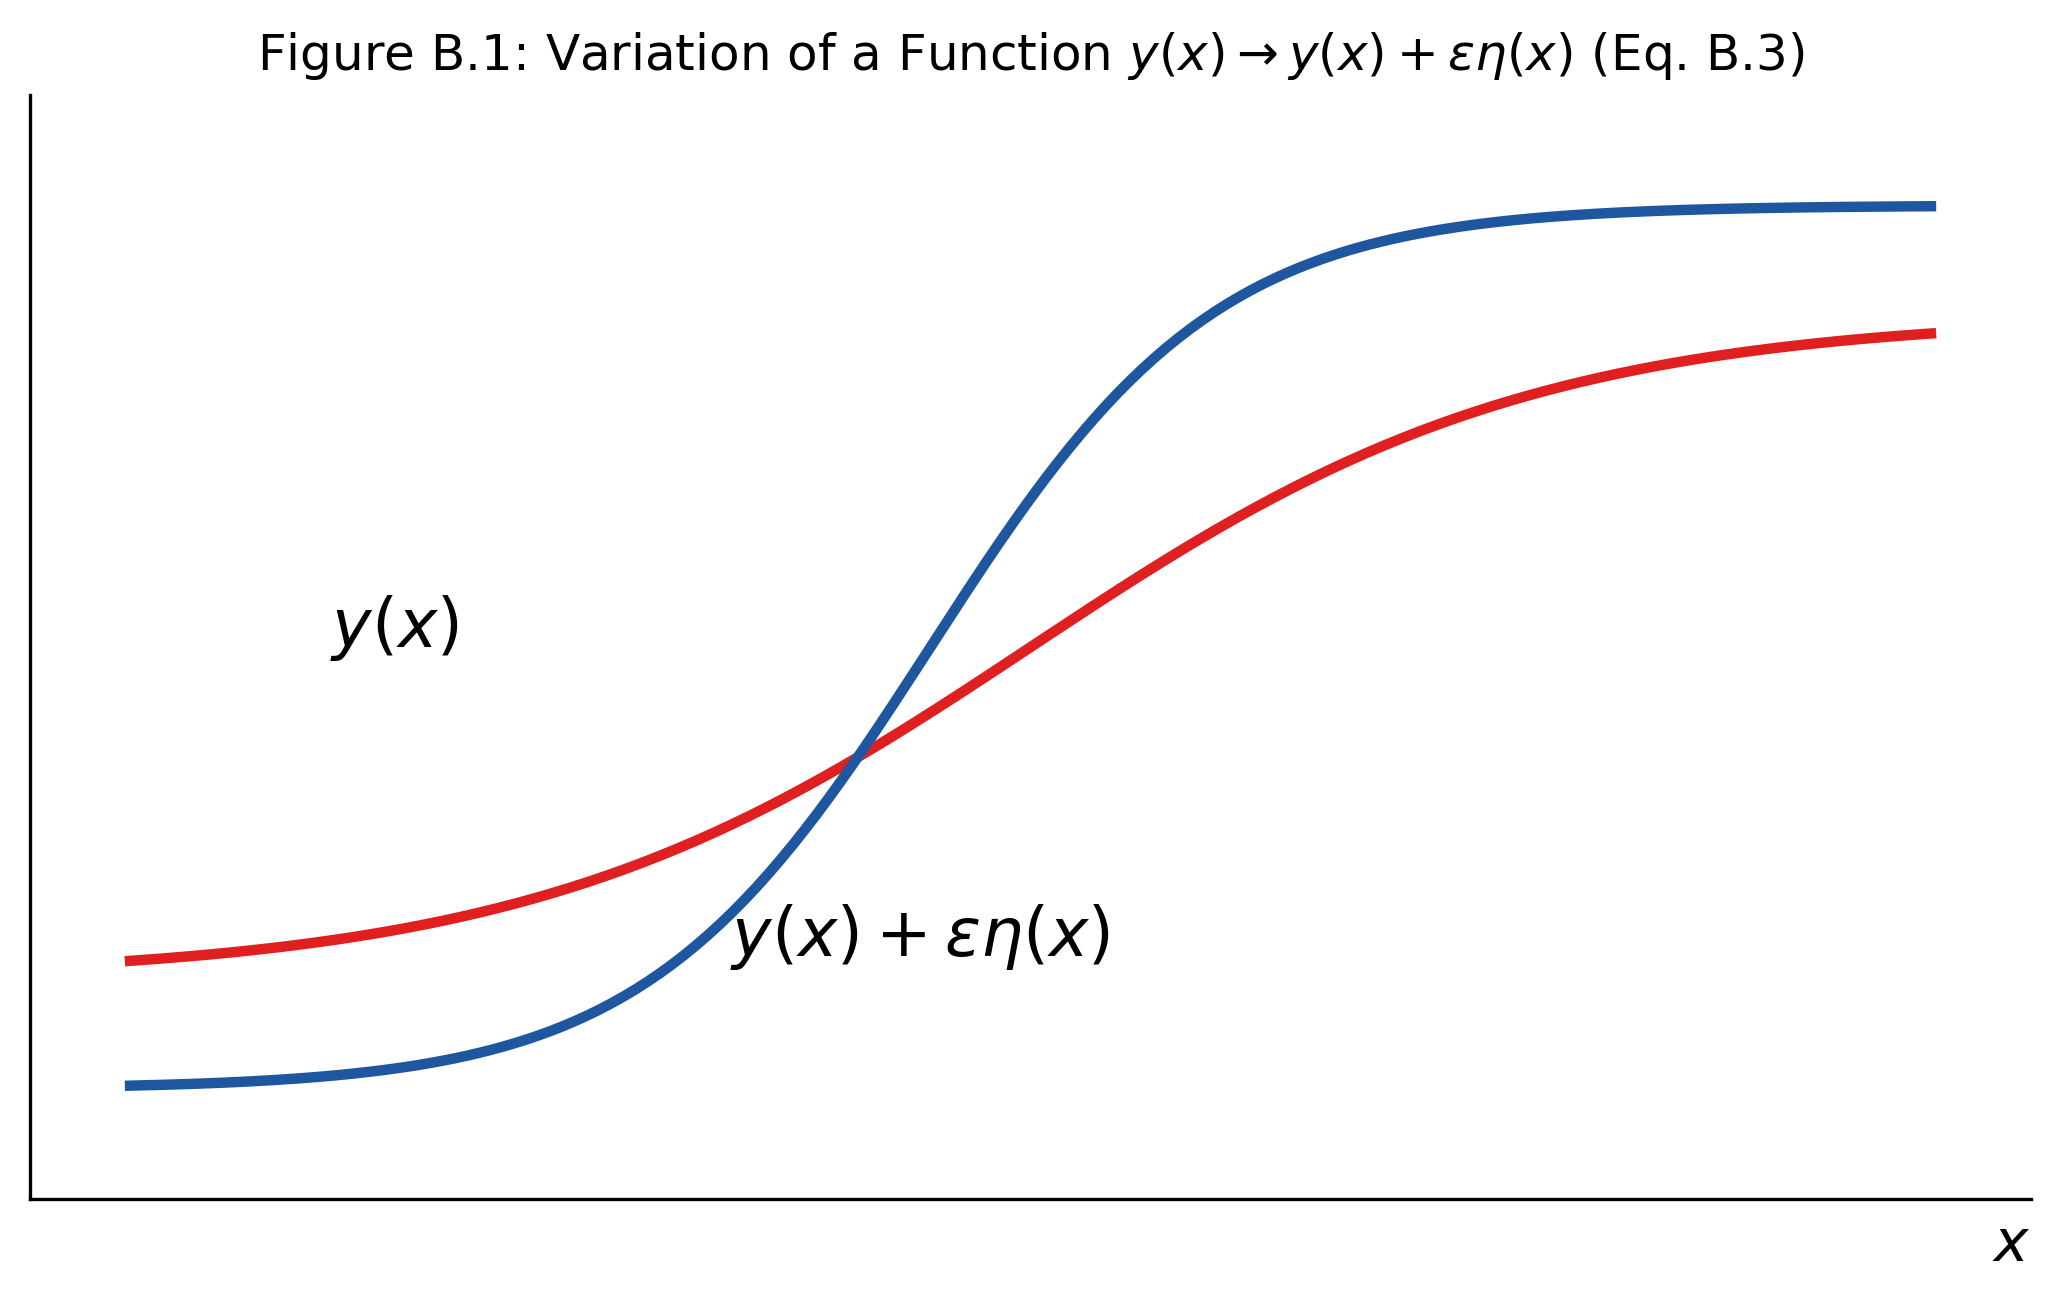

--- Figure B.2: オイラー・ラグランジュ方程式の解と離散最適化の収束 (Eq. B.10) ---


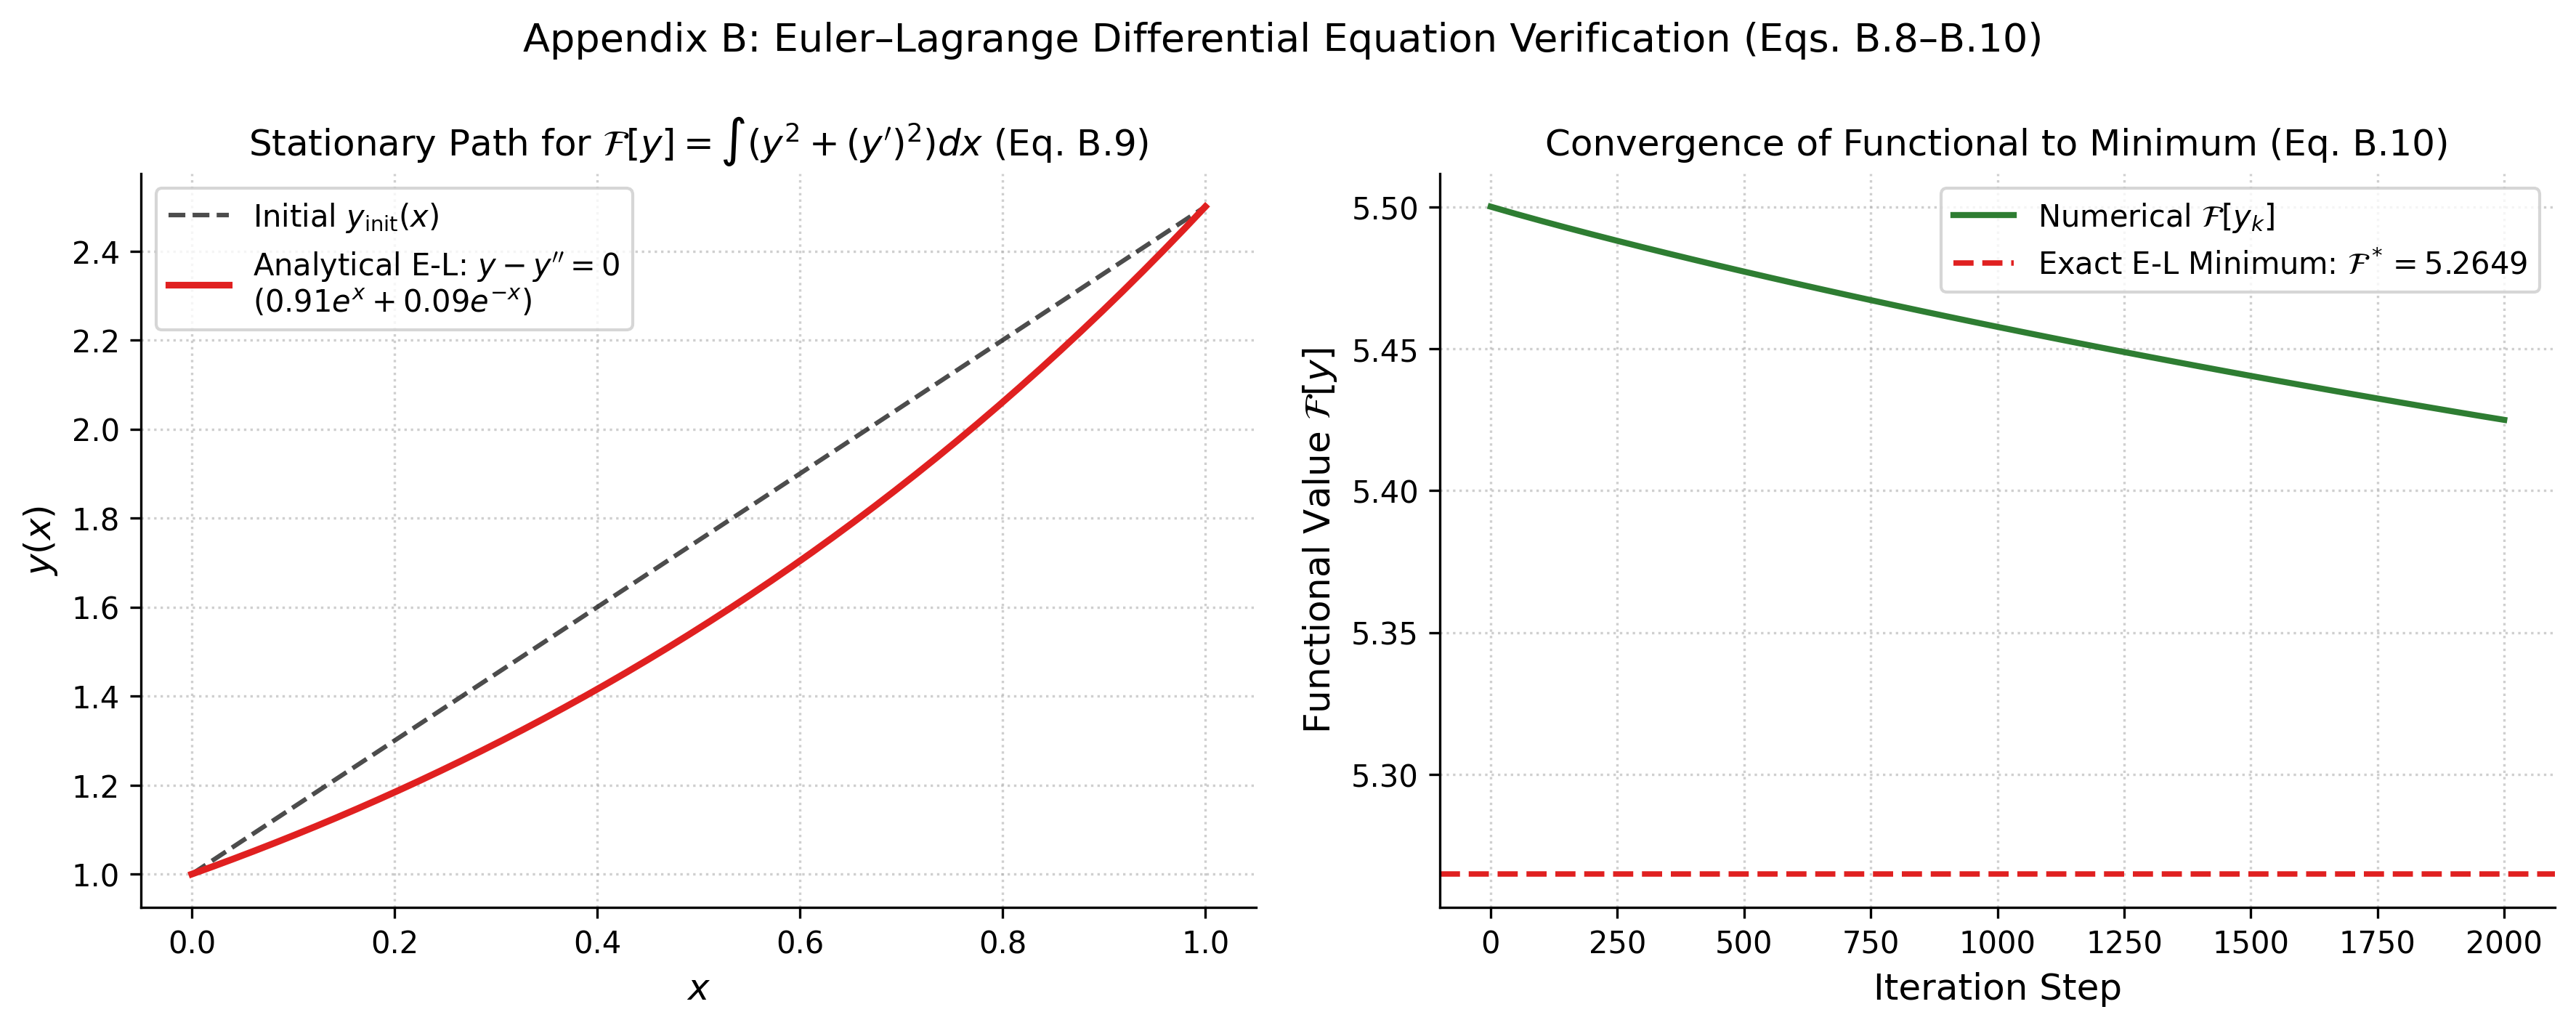

--- Figure B.3: 最大エントロピー原理 (同一分散下でのガウス分布の最大性) ---


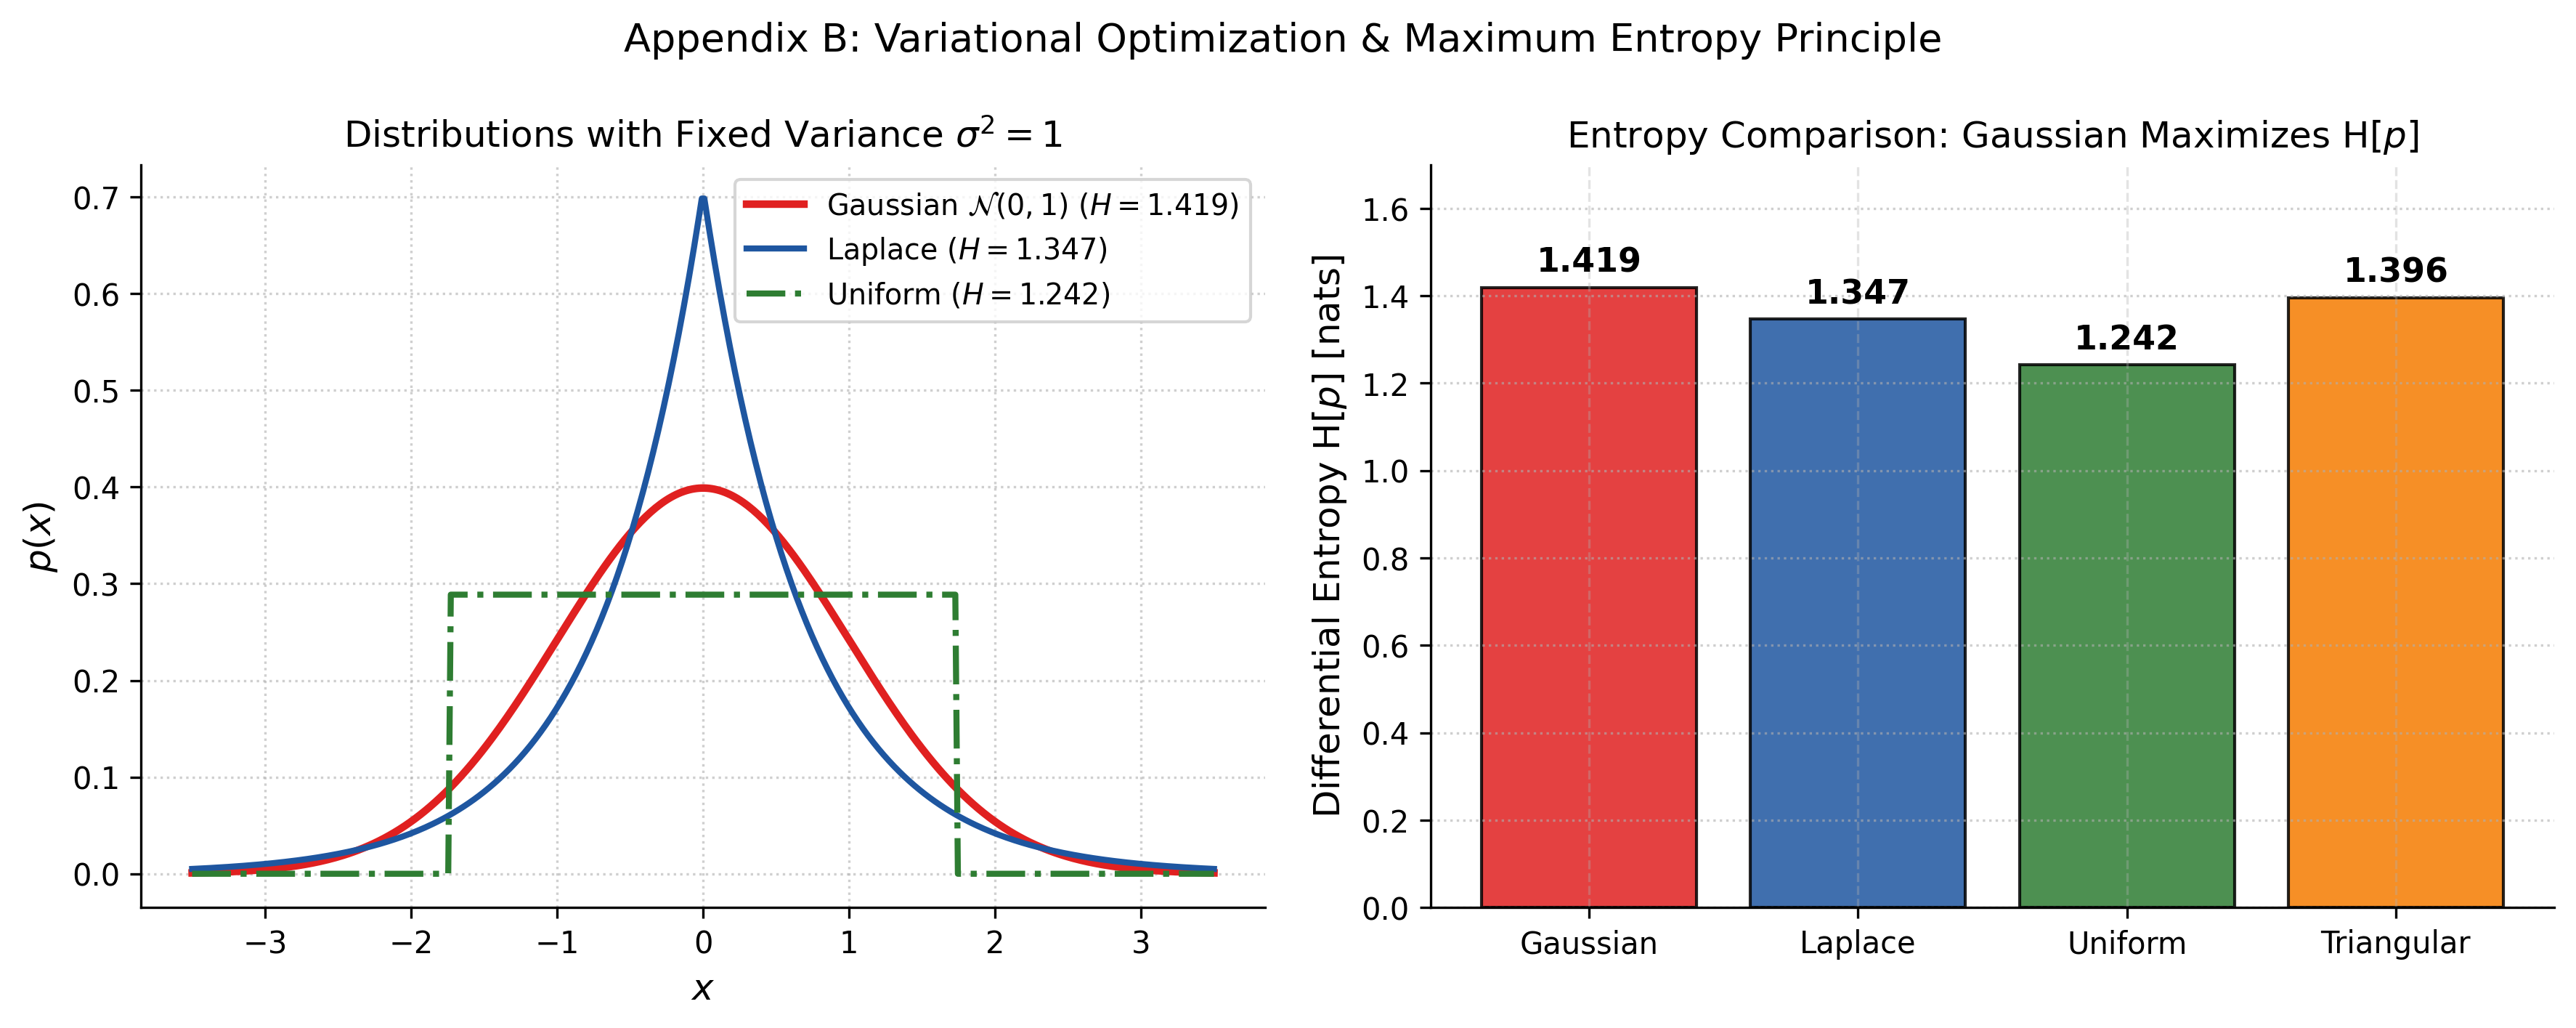

--- Figure B.4: 最短経路問題（ユークリッド平面の測地線としての直線） ---


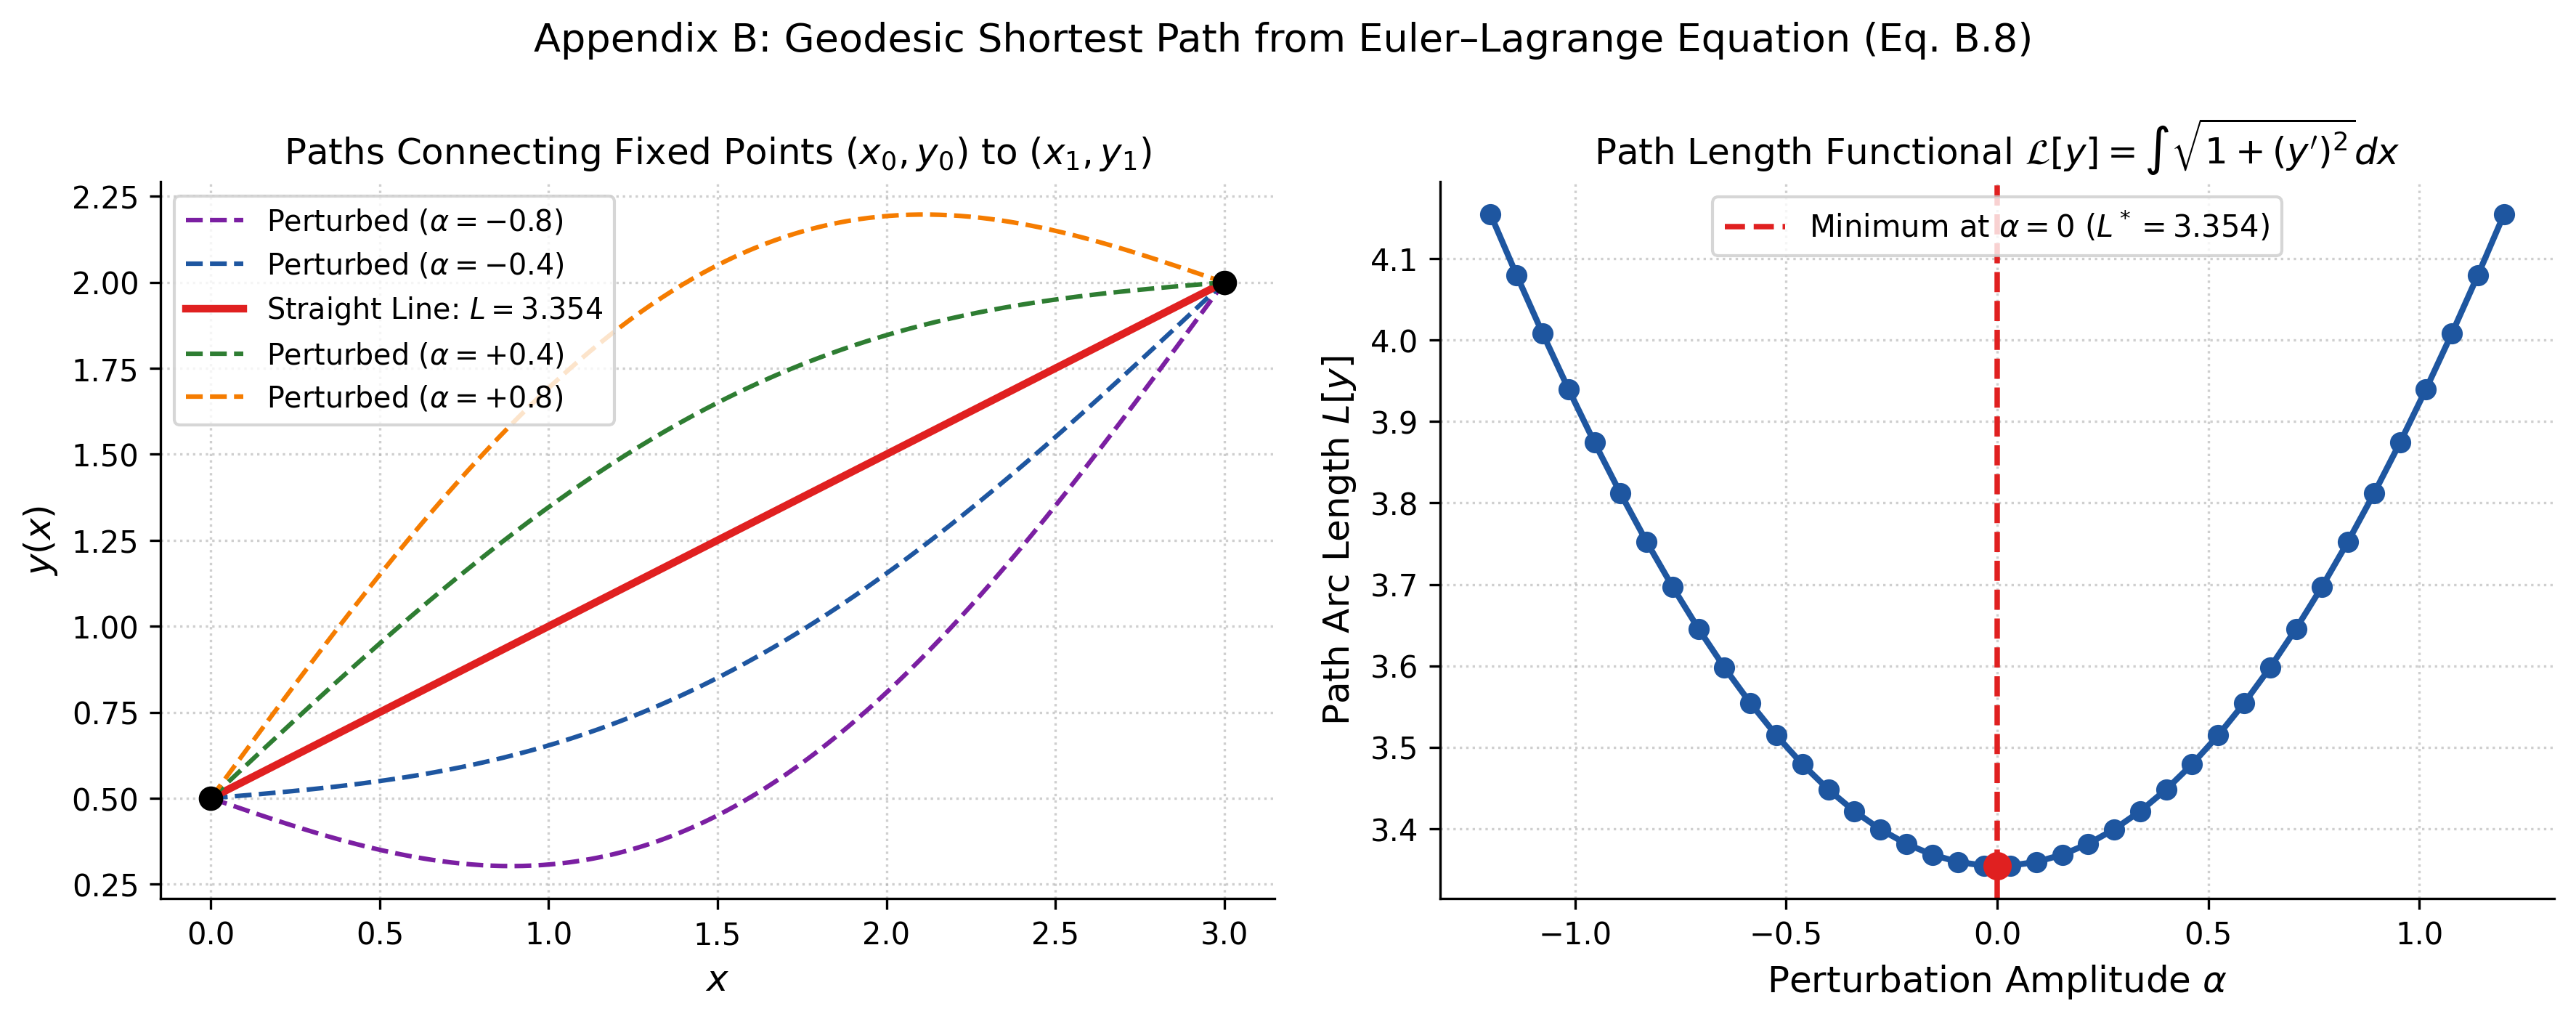

In [7]:
# === 生成された全図版のインライン表示 ===
from IPython.display import Image, display

fig_dir = repo_root / "appendix" / "result"
if not (fig_dir / "figB_1_functional_derivative.png").exists():
    fig_dir = Path("result")

print("--- Figure B.1: 変分導関数の幾何学的概念 (関数の摂動 y -> y + eps*eta) ---")
display(Image(filename=str(fig_dir / "figB_1_functional_derivative.png")))

print("--- Figure B.2: オイラー・ラグランジュ方程式の解と離散最適化の収束 (Eq. B.10) ---")
display(Image(filename=str(fig_dir / "figB_2_euler_lagrange_solution.png")))

print("--- Figure B.3: 最大エントロピー原理 (同一分散下でのガウス分布の最大性) ---")
display(Image(filename=str(fig_dir / "figB_3_maximum_entropy.png")))

print("--- Figure B.4: 最短経路問題（ユークリッド平面の測地線としての直線） ---")
display(Image(filename=str(fig_dir / "figB_4_shortest_path.png")))


---

## まとめと深層学習への示唆

本付録では、『深層学習：基礎と概念』付録 B「変分法」のすべての概念と数式（式 B.1 〜 B.10）を網羅し、厳密な導出とPythonによる検証を行いました。

### 主要な知見の総括
1. **変分導関数 (式 B.3 〜 B.4)**:
   微小摂動 $\epsilon \eta(x)$ による汎関数の変化量を捉え、多変量微分の概念を無限次元の関数空間に拡張します。
2. **オイラー・ラグランジュ方程式 (式 B.8)**:
   導関数を含む積分汎関数の停留条件を微分方程式に帰着させる強力な枠組みであり、最短経路問題（測地線）や物理学の最小作用の原理の数学的基礎となっています。
3. **最大エントロピー原理**:
   既知の平均・分散制約の下でエントロピーを最大化する分布がガウス分布であることは、深層学習や機械学習においてなぜ正規分布が事前分布やノイズモデルとして最も自然に選ばれるのかを正当化する最も強力な理論的根拠です。
4. **変分推論 (Variational Inference) への接続**:
   第19章の自己符号化器や第20章の拡散モデルにおけるエビデンス下界（ELBO）の最適化は、まさにこの変分法の原理をニューラルネットワークによってパラメータ化された関数族上で実行していることに他なりません。
